# Прогноз нагрузки на сервис по временным рядам

Учебный ML-проект: по почасовой истории `requests` прогнозируем нагрузку на следующие 24 часа.

Основной датасет в этой версии: **Calgary-HTTP** из Internet Traffic Archive. Это реальные HTTP-запросы к веб-серверу University of Calgary CS за период почти в год. Raw-лог агрегируем по часам в ряд:

```text
timestamp, requests
```

В первой версии сравниваем несколько подходов:

- `seasonal naive lag_24`: завтра будет похоже на последние 24 часа;
- `seasonal naive lag_168`: ближайшие сутки будут похожи на те же часы неделю назад;
- `LinearRegression`, `RandomForestRegressor` и `HistGradientBoostingRegressor` как классические ML-бейзлайны;
- `PyTorch nn.LSTM` как простая sequence-модель.

Модели кешируются в папке `models/`: при повторном запуске notebook загружает уже обученные модели, если `FORCE_RETRAIN = False`.

## 0. Импорты и настройки

Если какие-то библиотеки не установлены, добавь их в окружение, например:

```bash
uv add scikit-learn torch
```

В проекте с Python 3.14 PyTorch может потребовать отдельной проверки доступных wheel-файлов. Если установка `torch` не проходит, проще создать окружение на Python 3.11 или 3.12.

In [1]:
from pathlib import Path
import warnings
import json
import gzip
import re
import urllib.request
from collections import Counter
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FORCE_RETRAIN = False

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Notebook может запускаться из корня проекта или из папки notebooks.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
DEVICE

device(type='cpu')

## 1. Calgary-HTTP: реальные HTTP-запросы

Используем Calgary-HTTP из Internet Traffic Archive:

- raw-лог: `data/raw/calgary_access_log.gz`;
- подготовленный ряд: `data/processed/calgary_http_hourly.csv`;
- целевая переменная: количество HTTP-запросов за час, `requests`.

Если raw-файла или processed-файла нет, ячейка ниже может скачать raw-лог и заново собрать почасовую агрегацию.

In [2]:
CALGARY_HTTP_URL = "ftp://ita.ee.lbl.gov/traces/calgary_access_log.gz"
RAW_LOG_PATH = RAW_DATA_DIR / "calgary_access_log.gz"
HOURLY_DATA_PATH = PROCESSED_DATA_DIR / "calgary_http_hourly.csv"
TIMESTAMP_RE = re.compile(r"\[(\d{2}/[A-Za-z]{3}/\d{4}:\d{2}):\d{2}:\d{2} [+-]\d{4}\]")


def download_calgary_http(raw_path: Path = RAW_LOG_PATH, url: str = CALGARY_HTTP_URL) -> None:
    '''Download Calgary-HTTP raw log if it is missing.'''
    if raw_path.exists() and raw_path.stat().st_size > 0:
        return

    print(f"Downloading raw log to {raw_path} ...")
    with urllib.request.urlopen(url) as response:
        raw_path.write_bytes(response.read())


def prepare_calgary_hourly(raw_path: Path = RAW_LOG_PATH, output_path: Path = HOURLY_DATA_PATH) -> pd.DataFrame:
    '''Parse HTTP log timestamps and aggregate requests by hour.'''
    counts = Counter()
    total_lines = 0
    parsed_lines = 0

    with gzip.open(raw_path, "rt", encoding="latin1") as file:
        for line in file:
            total_lines += 1
            match = TIMESTAMP_RE.search(line)
            if not match:
                continue

            # Берём локальный час из лога. Для календарной сезонности это полезнее, чем UTC.
            timestamp_hour = datetime.strptime(match.group(1), "%d/%b/%Y:%H")
            counts[timestamp_hour] += 1
            parsed_lines += 1

    if not counts:
        raise ValueError(f"No timestamps parsed from {raw_path}")

    hourly_index = pd.date_range(min(counts), max(counts), freq="h")
    hourly_df = pd.DataFrame(
        {
            "timestamp": hourly_index,
            "requests": [counts.get(ts.to_pydatetime(), 0) for ts in hourly_index],
        }
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    hourly_df.to_csv(output_path, index=False)

    skipped_lines = total_lines - parsed_lines
    print(f"Saved hourly data to {output_path}")
    print(f"Parsed lines: {parsed_lines:,} / {total_lines:,}; skipped malformed lines: {skipped_lines:,}")

    return hourly_df


def load_calgary_hourly(force_rebuild: bool = False) -> pd.DataFrame:
    '''Load prepared hourly series, rebuilding it from raw log when needed.'''
    download_calgary_http()

    if force_rebuild or not HOURLY_DATA_PATH.exists():
        data = prepare_calgary_hourly()
    else:
        data = pd.read_csv(HOURLY_DATA_PATH, parse_dates=["timestamp"])

    data = data.sort_values("timestamp").reset_index(drop=True)
    data["requests"] = data["requests"].astype(int)
    return data


df = load_calgary_hourly()

print(df.shape)
print(f"Period: {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"Total requests in hourly series: {df['requests'].sum():,}")
print(f"Zero-request hours: {(df['requests'] == 0).sum():,}")

display(df.head())
display(df.tail())
display(df["requests"].describe().to_frame())

(8450, 2)
Period: 1994-10-24 13:00:00 -> 1995-10-11 14:00:00
Total requests in hourly series: 725,125
Zero-request hours: 167


,timestamp,requests
0,1994-10-24 13:00:00,33
1,1994-10-24 14:00:00,87
2,1994-10-24 15:00:00,192
3,1994-10-24 16:00:00,106
4,1994-10-24 17:00:00,73


,timestamp,requests
8445,1995-10-11 10:00:00,473
8446,1995-10-11 11:00:00,328
8447,1995-10-11 12:00:00,308
8448,1995-10-11 13:00:00,308
8449,1995-10-11 14:00:00,89


,requests
count,8450.000000
mean,85.813609
std,88.863708
min,0.000000
25%,25.000000
50%,60.000000
75%,115.000000
max,956.000000


## 2. EDA: временной ряд и сезонность

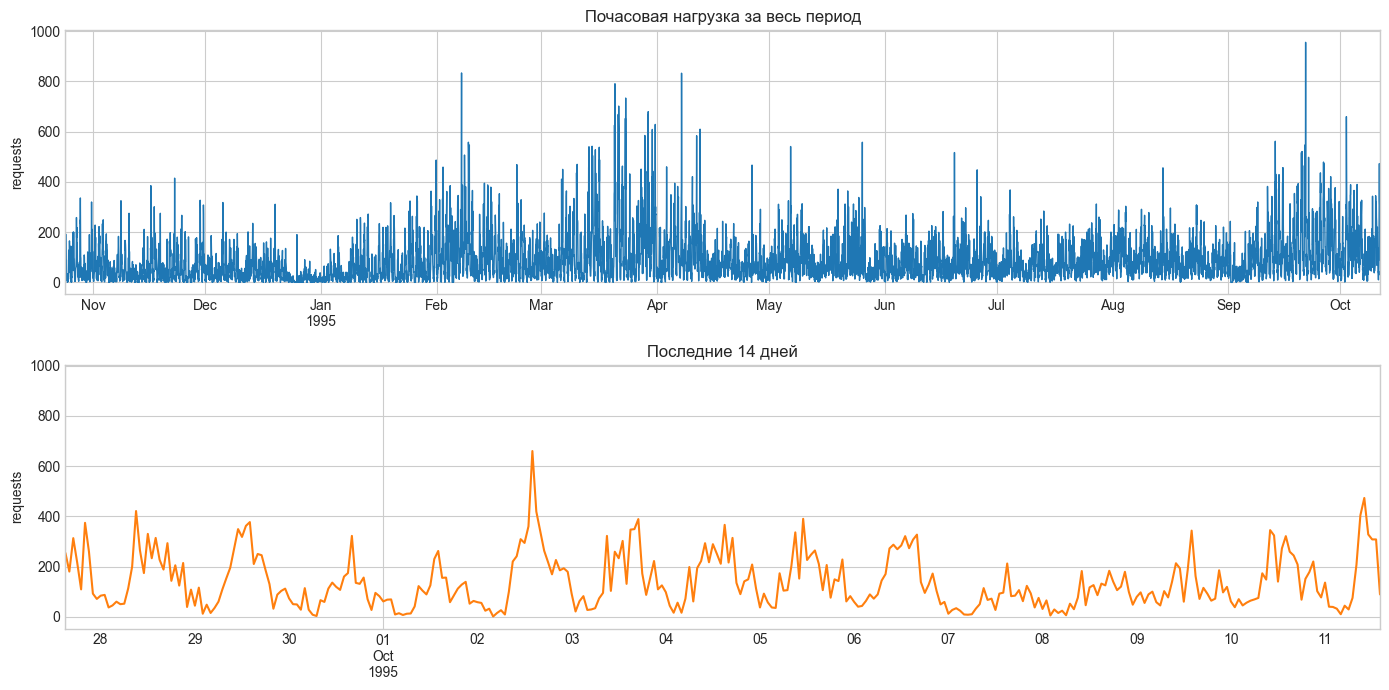

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

series = df.set_index("timestamp")["requests"]
series.plot(ax=axes[0], linewidth=1)
axes[0].set_title("Почасовая нагрузка за весь период")
axes[0].set_xlabel("")
axes[0].set_ylabel("requests")

series.tail(14 * 24).plot(ax=axes[1], linewidth=1.5, color="tab:orange")
axes[1].set_title("Последние 14 дней")
axes[1].set_xlabel("")
axes[1].set_ylabel("requests")

plt.tight_layout()

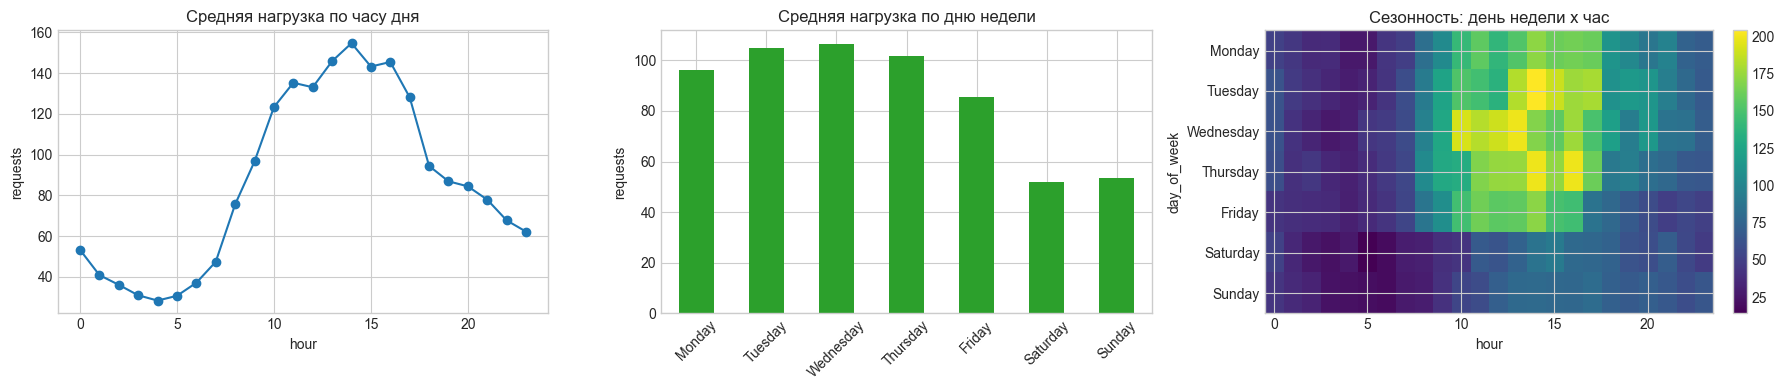

In [4]:
eda_df = df.copy()
eda_df["hour"] = eda_df["timestamp"].dt.hour
eda_df["day_of_week"] = eda_df["timestamp"].dt.dayofweek
eda_df["weekday_name"] = eda_df["timestamp"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hourly_profile = eda_df.groupby("hour")["requests"].mean()
weekday_profile = eda_df.groupby("weekday_name")["requests"].mean().reindex(weekday_order)
seasonality_matrix = eda_df.pivot_table(
    index="day_of_week",
    columns="hour",
    values="requests",
    aggfunc="mean",
).reindex(range(7))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly_profile.plot(ax=axes[0], marker="o")
axes[0].set_title("Средняя нагрузка по часу дня")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("requests")

weekday_profile.plot(kind="bar", ax=axes[1], color="tab:green")
axes[1].set_title("Средняя нагрузка по дню недели")
axes[1].set_xlabel("")
axes[1].set_ylabel("requests")
axes[1].tick_params(axis="x", rotation=45)

image = axes[2].imshow(seasonality_matrix, aspect="auto", cmap="viridis")
axes[2].set_title("Сезонность: день недели x час")
axes[2].set_xlabel("hour")
axes[2].set_ylabel("day_of_week")
axes[2].set_yticks(range(7), weekday_order)
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

## 3. Feature engineering

Признаки делаем только из прошлого и календаря:

- `hour`;
- `day_of_week`;
- `is_weekend`;
- `lag_1`;
- `lag_24`;
- `lag_168`;
- `rolling_mean_24`.

`rolling_mean_24` считается через `shift(1)`, чтобы не заглядывать в целевой час.

In [5]:
def make_features(data: pd.DataFrame) -> pd.DataFrame:
    '''Create calendar and lag features for one-step tabular forecasting.'''
    result = data.copy()
    result["hour"] = result["timestamp"].dt.hour
    result["day_of_week"] = result["timestamp"].dt.dayofweek
    result["is_weekend"] = (result["day_of_week"] >= 5).astype(int)

    result["lag_1"] = result["requests"].shift(1)
    result["lag_24"] = result["requests"].shift(24)
    result["lag_168"] = result["requests"].shift(168)
    result["rolling_mean_24"] = result["requests"].shift(1).rolling(window=24).mean()

    return result.dropna().reset_index(drop=True)


feature_df = make_features(df)
feature_columns = ["hour", "day_of_week", "is_weekend", "lag_1", "lag_24", "lag_168", "rolling_mean_24"]

display(feature_df.head())
print(f"Rows after lag features: {len(feature_df):,}")

,timestamp,requests,hour,day_of_week,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24
0,1994-10-31 13:00:00,320,13,0,0,174.0,47.0,33.0,51.750
1,1994-10-31 14:00:00,144,14,0,0,320.0,9.0,87.0,63.125
2,1994-10-31 15:00:00,85,15,0,0,144.0,88.0,192.0,68.750
3,1994-10-31 16:00:00,211,16,0,0,85.0,58.0,106.0,68.625
4,1994-10-31 17:00:00,179,17,0,0,211.0,34.0,73.0,75.000


Rows after lag features: 8,282


## 4. Time-based split и окна для прогноза на 24 часа

Для честного сравнения используем прямой прогноз на 24 часа. Каждый пример состоит из:

- истории за последние 168 часов;
- табличных признаков на момент последнего известного часа;
- целевого вектора из следующих 24 значений `requests`.

Разбиение делаем по времени: train → validation → test, без перемешивания.

In [6]:
HISTORY_SIZE = 168
HORIZON = 24


def make_forecast_windows(data: pd.DataFrame, history_size: int = HISTORY_SIZE, horizon: int = HORIZON):
    values = data["requests"].to_numpy(dtype=np.float32)
    timestamps = data["timestamp"].reset_index(drop=True)

    X_seq, X_tab, y, forecast_starts = [], [], [], []

    # end_idx - первый час, который нужно спрогнозировать.
    for end_idx in range(history_size, len(data) - horizon + 1):
        history = values[end_idx - history_size : end_idx]
        target = values[end_idx : end_idx + horizon]
        origin_ts = timestamps.iloc[end_idx - 1]
        forecast_start = timestamps.iloc[end_idx]

        tab_features = [
            origin_ts.hour,
            origin_ts.dayofweek,
            int(origin_ts.dayofweek >= 5),
            history[-1],
            history[-24],
            history[-168],
            history[-24:].mean(),
        ]

        X_seq.append(history.reshape(-1, 1))
        X_tab.append(tab_features)
        y.append(target)
        forecast_starts.append(forecast_start)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(X_tab, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.Series(forecast_starts, name="forecast_start"),
    )


X_seq, X_tab, y, forecast_starts = make_forecast_windows(df)

n_samples = len(y)
train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

X_seq_train, X_seq_val, X_seq_test = X_seq[:train_end], X_seq[train_end:val_end], X_seq[val_end:]
X_tab_train, X_tab_val, X_tab_test = X_tab[:train_end], X_tab[train_end:val_end], X_tab[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
starts_train, starts_val, starts_test = forecast_starts[:train_end], forecast_starts[train_end:val_end], forecast_starts[val_end:]

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(y_train), len(y_val), len(y_test)],
        "first_forecast_start": [starts_train.iloc[0], starts_val.iloc[0], starts_test.iloc[0]],
        "last_forecast_start": [starts_train.iloc[-1], starts_val.iloc[-1], starts_test.iloc[-1]],
    }
)

display(split_summary)
print("X_seq:", X_seq.shape, "X_tab:", X_tab.shape, "y:", y.shape)

,split,rows,first_forecast_start,last_forecast_start
0,train,5781,1994-10-31 13:00:00,1995-06-29 09:00:00
1,validation,1239,1995-06-29 10:00:00,1995-08-20 00:00:00
2,test,1239,1995-08-20 01:00:00,1995-10-10 15:00:00


X_seq: (8259, 168, 1) X_tab: (8259, 7) y: (8259, 24)


## 5. Метрики

Используем три метрики:

- `MAE`: средняя абсолютная ошибка;
- `RMSE`: корень из средней квадратичной ошибки;
- `sMAPE`: симметричная MAPE в процентах.

In [7]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    numerator = 2 * np.abs(y_pred - y_true)
    denominator = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100 * np.mean(numerator / denominator))


def evaluate_forecast(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "model": name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }

## 6. Baseline: seasonal naive

Идея seasonal naive проста: использовать уже наблюдавшиеся значения с тем же сезонным сдвигом.

- `lag_24`: последние 24 часа становятся прогнозом на следующие 24 часа;
- `lag_168`: берём те же 24 часа неделю назад.

In [8]:
def seasonal_naive_from_history(X_seq_values: np.ndarray, period: int, horizon: int = HORIZON) -> np.ndarray:
    '''Build direct 24-hour seasonal naive forecast from historical windows.'''
    history = X_seq_values[:, :, 0]

    if period == 24:
        return history[:, -horizon:]
    if period == 168:
        return history[:, -period : -period + horizon]

    raise ValueError("This notebook expects period 24 or 168.")


pred_lag_24_val = seasonal_naive_from_history(X_seq_val, period=24)
pred_lag_168_val = seasonal_naive_from_history(X_seq_val, period=168)
pred_lag_24_test = seasonal_naive_from_history(X_seq_test, period=24)
pred_lag_168_test = seasonal_naive_from_history(X_seq_test, period=168)

baseline_results_val = pd.DataFrame(
    [
        evaluate_forecast("seasonal_naive_lag_24", y_val, pred_lag_24_val),
        evaluate_forecast("seasonal_naive_lag_168", y_val, pred_lag_168_val),
    ]
)

baseline_results_test = pd.DataFrame(
    [
        evaluate_forecast("seasonal_naive_lag_24", y_test, pred_lag_24_test),
        evaluate_forecast("seasonal_naive_lag_168", y_test, pred_lag_168_test),
    ]
)

display(baseline_results_val.sort_values("MAE"))
display(baseline_results_test.sort_values("MAE"))

,model,MAE,RMSE,sMAPE
1,seasonal_naive_lag_168,46.676991,63.517925,63.990219
0,seasonal_naive_lag_24,48.920803,66.103485,66.215179


,model,MAE,RMSE,sMAPE
0,seasonal_naive_lag_24,60.752018,89.522812,61.946903
1,seasonal_naive_lag_168,61.301857,91.767265,63.221214


## 7. Linear Regression, Random Forest и Boosting baseline

Эти модели получают компактные признаки на момент последнего известного часа и сразу предсказывают 24 значения.

Табличные признаки совпадают с постановкой задачи:

`hour`, `day_of_week`, `is_weekend`, `lag_1`, `lag_24`, `lag_168`, `rolling_mean_24`.

Для boosting используем `HistGradientBoostingRegressor` из sklearn через `MultiOutputRegressor`, потому что нам нужен прогноз сразу на 24 часа.

In [9]:
tabular_feature_names = [
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
]

linear_model_path = MODELS_DIR / "linear_regression_forecaster.joblib"
forest_model_path = MODELS_DIR / "random_forest_forecaster.joblib"
boosting_model_path = MODELS_DIR / "hist_gradient_boosting_forecaster.joblib"


def fit_or_load_joblib_model(model, model_path: Path, X_train: np.ndarray, y_train: np.ndarray):
    '''Load a cached sklearn model or train and save it.'''
    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Loaded cached model: {model_path}")
        cached_model = joblib.load(model_path)
        if isinstance(cached_model, MultiOutputRegressor):
            cached_model.n_jobs = 1
        return cached_model

    print(f"Training model: {model_path.name}")
    model.fit(X_train, y_train)
    joblib.dump(model, model_path)
    print(f"Saved model: {model_path}")
    return model


linear_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=14,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

boosting_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    ),
    n_jobs=1,
)

linear_model = fit_or_load_joblib_model(linear_model, linear_model_path, X_tab_train, y_train)
forest_model = fit_or_load_joblib_model(forest_model, forest_model_path, X_tab_train, y_train)
boosting_model = fit_or_load_joblib_model(boosting_model, boosting_model_path, X_tab_train, y_train)

pred_linear_val = linear_model.predict(X_tab_val)
pred_forest_val = forest_model.predict(X_tab_val)
pred_boosting_val = boosting_model.predict(X_tab_val)

pred_linear_test = linear_model.predict(X_tab_test)
pred_forest_test = forest_model.predict(X_tab_test)
pred_boosting_test = boosting_model.predict(X_tab_test)

ml_results_val = pd.DataFrame(
    [
        evaluate_forecast("linear_regression", y_val, pred_linear_val),
        evaluate_forecast("random_forest", y_val, pred_forest_val),
        evaluate_forecast("hist_gradient_boosting", y_val, pred_boosting_val),
    ]
)

ml_results_test = pd.DataFrame(
    [
        evaluate_forecast("linear_regression", y_test, pred_linear_test),
        evaluate_forecast("random_forest", y_test, pred_forest_test),
        evaluate_forecast("hist_gradient_boosting", y_test, pred_boosting_test),
    ]
)

display(pd.concat([baseline_results_val, ml_results_val]).sort_values("MAE"))
display(pd.concat([baseline_results_test, ml_results_test]).sort_values("MAE"))

Loaded cached model: C:\Users\on_th\PycharmProjects\JupyterProject\models\linear_regression_forecaster.joblib
Loaded cached model: C:\Users\on_th\PycharmProjects\JupyterProject\models\random_forest_forecaster.joblib
Loaded cached model: C:\Users\on_th\PycharmProjects\JupyterProject\models\hist_gradient_boosting_forecaster.joblib


,model,MAE,RMSE,sMAPE
1,random_forest,36.303549,49.615361,50.143911
2,hist_gradient_boosting,36.878298,50.403347,50.912848
0,linear_regression,39.058910,51.666943,55.548729
1,seasonal_naive_lag_168,46.676991,63.517925,63.990219
0,seasonal_naive_lag_24,48.920803,66.103485,66.215179


,model,MAE,RMSE,sMAPE
1,random_forest,45.843827,68.227811,47.159710
2,hist_gradient_boosting,48.732377,72.405178,49.431104
0,linear_regression,58.194382,82.665428,58.271156
0,seasonal_naive_lag_24,60.752018,89.522812,61.946903
1,seasonal_naive_lag_168,61.301857,91.767265,63.221214


## 8. Небольшой подбор гиперпараметров

Старый блок выше показывает базовые настройки моделей. Теперь сделаем компактный ручной grid search:

- подбираем параметры только на `validation`;
- `test` не используем для выбора модели, только для финальной проверки;
- результаты и лучшие tuned-модели сохраняем в `models/`, чтобы не обучать их заново при каждом запуске.

Это не исчерпывающий AutoML, а учебный и воспроизводимый подбор нескольких разумных конфигураций.

In [10]:
rf_tuned_model_path = MODELS_DIR / "random_forest_tuned.joblib"
boosting_tuned_model_path = MODELS_DIR / "hist_gradient_boosting_tuned.joblib"
tuning_results_path = MODELS_DIR / "tabular_tuning_results.csv"

rf_tuning_grid = [
    {"n_estimators": 200, "max_depth": 14, "min_samples_leaf": 3, "max_features": 1.0},
    {"n_estimators": 300, "max_depth": 16, "min_samples_leaf": 3, "max_features": 1.0},
    {"n_estimators": 300, "max_depth": 18, "min_samples_leaf": 5, "max_features": 1.0},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 5, "max_features": 1.0},
    {"n_estimators": 300, "max_depth": 16, "min_samples_leaf": 5, "max_features": 0.8},
    {"n_estimators": 400, "max_depth": 12, "min_samples_leaf": 2, "max_features": 1.0},
]

boosting_tuning_grid = [
    {"max_iter": 250, "learning_rate": 0.05, "max_leaf_nodes": 31, "l2_regularization": 0.01},
    {"max_iter": 200, "learning_rate": 0.04, "max_leaf_nodes": 31, "l2_regularization": 0.05},
    {"max_iter": 300, "learning_rate": 0.03, "max_leaf_nodes": 31, "l2_regularization": 0.05},
    {"max_iter": 200, "learning_rate": 0.05, "max_leaf_nodes": 15, "l2_regularization": 0.05},
    {"max_iter": 300, "learning_rate": 0.03, "max_leaf_nodes": 15, "l2_regularization": 0.10},
    {"max_iter": 200, "learning_rate": 0.08, "max_leaf_nodes": 15, "l2_regularization": 0.10},
]


def make_random_forest(params: dict) -> RandomForestRegressor:
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)


def make_boosting(params: dict) -> MultiOutputRegressor:
    base_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    return MultiOutputRegressor(base_model, n_jobs=1)


def run_validation_search(model_name: str, grid: list[dict], model_factory):
    results = []
    best_model = None
    best_row = None

    for params in grid:
        print(f"Training {model_name}: {params}")
        candidate = model_factory(params)
        candidate.fit(X_tab_train, y_train)
        prediction = candidate.predict(X_tab_val)
        row = evaluate_forecast(model_name, y_val, prediction)
        row["params"] = json.dumps(params, ensure_ascii=False)
        results.append(row)

        if best_row is None or row["MAE"] < best_row["MAE"]:
            best_row = row
            best_model = candidate

    return pd.DataFrame(results), best_model, best_row


def load_or_tune_tabular_models():
    cache_exists = (
        rf_tuned_model_path.exists()
        and boosting_tuned_model_path.exists()
        and tuning_results_path.exists()
    )

    if cache_exists and not FORCE_RETRAIN:
        print("Loaded cached tuned tabular models.")
        rf_model = joblib.load(rf_tuned_model_path)
        boosting_model = joblib.load(boosting_tuned_model_path)
        tuning_results = pd.read_csv(tuning_results_path)
        return rf_model, boosting_model, tuning_results

    rf_results, rf_model, rf_best = run_validation_search(
        "random_forest_tuned",
        rf_tuning_grid,
        make_random_forest,
    )
    boosting_results, boosting_model, boosting_best = run_validation_search(
        "hist_gradient_boosting_tuned",
        boosting_tuning_grid,
        make_boosting,
    )

    tuning_results = pd.concat([rf_results, boosting_results], ignore_index=True).sort_values("MAE")
    tuning_results.to_csv(tuning_results_path, index=False)
    joblib.dump(rf_model, rf_tuned_model_path)
    joblib.dump(boosting_model, boosting_tuned_model_path)

    print(f"Saved tuned random forest: {rf_tuned_model_path}")
    print(f"Saved tuned boosting: {boosting_tuned_model_path}")
    print(f"Saved tuning table: {tuning_results_path}")
    return rf_model, boosting_model, tuning_results


rf_tuned_model, boosting_tuned_model, tuning_results = load_or_tune_tabular_models()

display(tuning_results.sort_values("MAE"))

pred_rf_tuned_val = rf_tuned_model.predict(X_tab_val)
pred_boosting_tuned_val = boosting_tuned_model.predict(X_tab_val)
pred_rf_tuned_test = rf_tuned_model.predict(X_tab_test)
pred_boosting_tuned_test = boosting_tuned_model.predict(X_tab_test)

tuned_results_val = pd.DataFrame(
    [
        evaluate_forecast("random_forest_tuned", y_val, pred_rf_tuned_val),
        evaluate_forecast("hist_gradient_boosting_tuned", y_val, pred_boosting_tuned_val),
    ]
)

tuned_results_test = pd.DataFrame(
    [
        evaluate_forecast("random_forest_tuned", y_test, pred_rf_tuned_test),
        evaluate_forecast("hist_gradient_boosting_tuned", y_test, pred_boosting_tuned_test),
    ]
)

print("Validation: old vs tuned")
display(pd.concat([ml_results_val, tuned_results_val], ignore_index=True).sort_values("MAE"))

print("Test: old vs tuned")
display(pd.concat([ml_results_test, tuned_results_test], ignore_index=True).sort_values("MAE"))

Training random_forest_tuned: {'n_estimators': 200, 'max_depth': 14, 'min_samples_leaf': 3, 'max_features': 1.0}


Training random_forest_tuned: {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 3, 'max_features': 1.0}


Training random_forest_tuned: {'n_estimators': 300, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 1.0}


Training random_forest_tuned: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 1.0}


Training random_forest_tuned: {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 5, 'max_features': 0.8}


...

,model,MAE,RMSE,sMAPE,params
4,random_forest_tuned,35.656712,48.581247,49.449057,"{""n_estimators"": 300, ""max_depth"": 16, ""min_sa..."
10,hist_gradient_boosting_tuned,35.947885,48.878556,49.910356,"{""max_iter"": 300, ""learning_rate"": 0.03, ""max_..."
9,hist_gradient_boosting_tuned,36.055324,49.052860,50.004474,"{""max_iter"": 200, ""learning_rate"": 0.05, ""max_..."
2,random_forest_tuned,36.077616,49.238841,49.846570,"{""n_estimators"": 300, ""max_depth"": 18, ""min_sa..."
3,random_forest_tuned,36.077784,49.238938,49.846845,"{""n_estimators"": 300, ""max_depth"": null, ""min_..."
5,random_forest_tuned,36.180062,49.576293,50.035374,"{""n_estimators"": 400, ""max_depth"": 12, ""min_sa..."
0,random_forest_tuned,36.303549,49.615361,50.143911,"{""n_estimators"": 200, ""max_depth"": 14, ""min_sa..."
1,random_forest_tuned,36.400990,49.710299,50.243443,"{""n_estimators"": 300, ""max_depth"": 16, ""min_sa..."
7,hist_gradient_boosting_tuned,36.407094,49.808437,50.315679,"{""max_iter"": 200, ""learning_rate"": 0.04, ""max_..."
11,hist_gradient_boosting_tuned,36.417158,49.531076,50.460712,"{""max_iter"": 200, ""learning_rate"": 0.08, ""max_..."


Validation: old vs tuned


,model,MAE,RMSE,sMAPE
3,random_forest_tuned,35.656712,48.581247,49.449057
4,hist_gradient_boosting_tuned,35.947885,48.878556,49.910356
1,random_forest,36.303549,49.615361,50.143911
2,hist_gradient_boosting,36.878298,50.403347,50.912848
0,linear_regression,39.058910,51.666943,55.548729


Test: old vs tuned


,model,MAE,RMSE,sMAPE
3,random_forest_tuned,45.021597,67.028003,46.485147
1,random_forest,45.843827,68.227811,47.159710
4,hist_gradient_boosting_tuned,46.665660,69.461357,47.432034
2,hist_gradient_boosting,48.732377,72.405178,49.431104
0,linear_regression,58.194382,82.665428,58.271156


## 8. PyTorch LSTM model

LSTM получает последовательность формы `[batch, 168, 1]` и возвращает прогноз `[batch, 24]`.

Перед обучением нормализуем `requests` по среднему и стандартному отклонению train-части. Это важно для стабильного обучения нейросети.

In [11]:
request_mean = float(X_seq_train.reshape(-1).mean())
request_std = float(X_seq_train.reshape(-1).std())

print(f"Train mean: {request_mean:.2f}")
print(f"Train std:  {request_std:.2f}")


class LoadForecastDataset(Dataset):
    def __init__(self, X_seq_values: np.ndarray, y_values: np.ndarray, mean: float, std: float):
        self.X = torch.tensor((X_seq_values - mean) / std, dtype=torch.float32)
        self.y = torch.tensor((y_values - mean) / std, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


train_dataset = LoadForecastDataset(X_seq_train, y_train, request_mean, request_std)
val_dataset = LoadForecastDataset(X_seq_val, y_val, request_mean, request_std)
test_dataset = LoadForecastDataset(X_seq_test, y_test, request_mean, request_std)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Train mean: 80.51
Train std:  90.09


In [12]:
class LSTMLoadForecaster(nn.Module):
    def __init__(
        self,
        input_size: int = 1,
        hidden_size: int = 64,
        num_layers: int = 1,
        horizon: int = HORIZON,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.horizon = horizon
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, horizon),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sequence_output, _ = self.lstm(x)
        last_hidden = sequence_output[:, -1, :]
        return self.head(last_hidden)


lstm_model = LSTMLoadForecaster(hidden_size=64, num_layers=1, horizon=HORIZON).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_model

LSTMLoadForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=24, bias=True)
  )
)

## 9. Обучение LSTM

In [13]:
lstm_model_path = MODELS_DIR / "lstm_load_forecaster.pt"


def run_epoch(model: nn.Module, loader: DataLoader, optimizer=None) -> float:
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_items = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            prediction = model(X_batch)
            loss = criterion(prediction, y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = len(y_batch)
        total_loss += loss.item() * batch_size
        total_items += batch_size

    return total_loss / total_items


def is_lstm_checkpoint_compatible(checkpoint: dict) -> bool:
    config = checkpoint.get("config", {})
    normalization = checkpoint.get("normalization", {})

    expected_config = {
        "history_size": HISTORY_SIZE,
        "horizon": HORIZON,
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 1,
    }

    config_ok = all(config.get(key) == value for key, value in expected_config.items())
    mean_ok = np.isclose(normalization.get("request_mean", np.nan), request_mean)
    std_ok = np.isclose(normalization.get("request_std", np.nan), request_std)
    return bool(config_ok and mean_ok and std_ok)


EPOCHS = 25
PATIENCE = 5
history_df = pd.DataFrame()

if lstm_model_path.exists() and not FORCE_RETRAIN:
    checkpoint = torch.load(lstm_model_path, map_location=DEVICE)
    if is_lstm_checkpoint_compatible(checkpoint):
        lstm_model.load_state_dict(checkpoint["model_state_dict"])
        print(f"Loaded cached LSTM model: {lstm_model_path}")
    else:
        print("Cached LSTM is incompatible with current data/config; retraining.")
        FORCE_RETRAIN = True

if FORCE_RETRAIN or not lstm_model_path.exists():
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = run_epoch(lstm_model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(lstm_model, val_loader, optimizer=None)

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {name: param.detach().cpu().clone() for name, param in lstm_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping")
            break

    lstm_model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)

if not history_df.empty:
    history_df.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(8, 4), marker="o")
    plt.title("LSTM learning curve")
    plt.ylabel("MSE loss on normalized requests")
    plt.tight_layout()

Loaded cached LSTM model: C:\Users\on_th\PycharmProjects\JupyterProject\models\lstm_load_forecaster.pt


## 10. Оценка LSTM и сравнение моделей

In [14]:
def predict_lstm(model: nn.Module, loader: DataLoader, mean: float, std: float):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            pred_scaled = model(X_batch).cpu().numpy()
            y_scaled = y_batch.cpu().numpy()

            predictions.append(pred_scaled * std + mean)
            targets.append(y_scaled * std + mean)

    return np.vstack(targets), np.vstack(predictions)


lstm_val_true, lstm_val_pred = predict_lstm(lstm_model, val_loader, request_mean, request_std)
lstm_test_true, lstm_test_pred = predict_lstm(lstm_model, test_loader, request_mean, request_std)

lstm_results_val = pd.DataFrame([evaluate_forecast("pytorch_lstm", lstm_val_true, lstm_val_pred)])
lstm_results_test = pd.DataFrame([evaluate_forecast("pytorch_lstm", lstm_test_true, lstm_test_pred)])

comparison_val = pd.concat([baseline_results_val, ml_results_val, tuned_results_val, lstm_results_val], ignore_index=True).sort_values("MAE")
comparison_test = pd.concat([baseline_results_test, ml_results_test, tuned_results_test, lstm_results_test], ignore_index=True).sort_values("MAE")

print("Validation metrics")
display(comparison_val)

print("Test metrics")
display(comparison_test)

Validation metrics


,model,MAE,RMSE,sMAPE
5,random_forest_tuned,35.656712,48.581247,49.449057
6,hist_gradient_boosting_tuned,35.947885,48.878556,49.910356
3,random_forest,36.303549,49.615361,50.143911
7,pytorch_lstm,36.632599,49.387482,51.427986
4,hist_gradient_boosting,36.878298,50.403347,50.912848
2,linear_regression,39.058910,51.666943,55.548729
1,seasonal_naive_lag_168,46.676991,63.517925,63.990219
0,seasonal_naive_lag_24,48.920803,66.103485,66.215179


Test metrics


,model,MAE,RMSE,sMAPE
5,random_forest_tuned,45.021597,67.028003,46.485147
3,random_forest,45.843827,68.227811,47.159710
6,hist_gradient_boosting_tuned,46.665660,69.461357,47.432034
4,hist_gradient_boosting,48.732377,72.405178,49.431104
7,pytorch_lstm,49.520969,75.441261,51.393681
2,linear_regression,58.194382,82.665428,58.271156
0,seasonal_naive_lag_24,60.752018,89.522812,61.946903
1,seasonal_naive_lag_168,61.301857,91.767265,63.221214


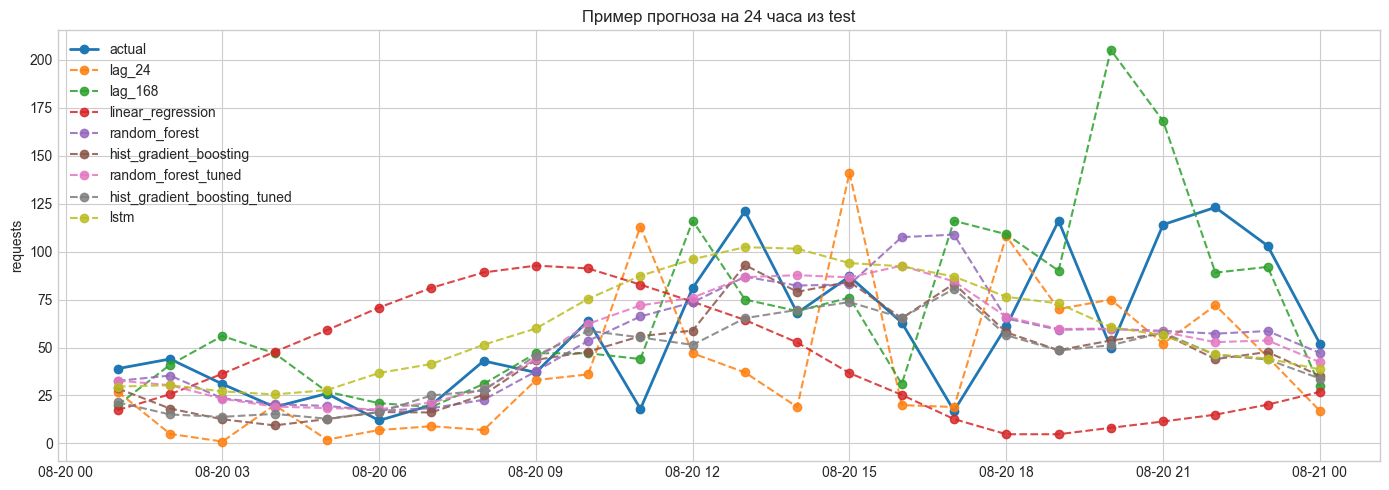

In [15]:
test_predictions = {
    "lag_24": pred_lag_24_test,
    "lag_168": pred_lag_168_test,
    "linear_regression": pred_linear_test,
    "random_forest": pred_forest_test,
    "hist_gradient_boosting": pred_boosting_test,
    "random_forest_tuned": pred_rf_tuned_test,
    "hist_gradient_boosting_tuned": pred_boosting_tuned_test,
    "lstm": lstm_test_pred,
}

window_idx = 0
forecast_index = pd.date_range(starts_test.iloc[window_idx], periods=HORIZON, freq="h")

plt.figure(figsize=(14, 5))
plt.plot(forecast_index, y_test[window_idx], marker="o", label="actual", linewidth=2)
for name, prediction in test_predictions.items():
    plt.plot(forecast_index, prediction[window_idx], marker="o", linestyle="--", label=name, alpha=0.85)

plt.title("Пример прогноза на 24 часа из test")
plt.xlabel("")
plt.ylabel("requests")
plt.legend()
plt.tight_layout()

## 11. Сохранение модели

In [16]:
model_path = lstm_model_path

torch.save(
    {
        "model_state_dict": lstm_model.state_dict(),
        "config": {
            "history_size": HISTORY_SIZE,
            "horizon": HORIZON,
            "input_size": 1,
            "hidden_size": 64,
            "num_layers": 1,
        },
        "normalization": {
            "request_mean": request_mean,
            "request_std": request_std,
        },
        "feature_columns": tabular_feature_names,
        "metrics_validation": comparison_val.to_dict(orient="records"),
        "metrics_test": comparison_test.to_dict(orient="records"),
    },
    model_path,
)

print(f"Saved LSTM model to: {model_path}")
print("Cached sklearn models:")
print(f"- {linear_model_path}")
print(f"- {forest_model_path}")
print(f"- {boosting_model_path}")
print(f"- {rf_tuned_model_path}")
print(f"- {boosting_tuned_model_path}")
print(f"- {tuning_results_path}")

Saved LSTM model to: C:\Users\on_th\PycharmProjects\JupyterProject\models\lstm_load_forecaster.pt
Cached sklearn models:
- C:\Users\on_th\PycharmProjects\JupyterProject\models\linear_regression_forecaster.joblib
- C:\Users\on_th\PycharmProjects\JupyterProject\models\random_forest_forecaster.joblib
- C:\Users\on_th\PycharmProjects\JupyterProject\models\hist_gradient_boosting_forecaster.joblib
- C:\Users\on_th\PycharmProjects\JupyterProject\models\random_forest_tuned.joblib
- C:\Users\on_th\PycharmProjects\JupyterProject\models\hist_gradient_boosting_tuned.joblib
- C:\Users\on_th\PycharmProjects\JupyterProject\models\tabular_tuning_results.csv


## 12. Прогноз следующих 24 часов

Ниже пример того, как получить прогноз сразу после последнего часа в датасете.

,timestamp,seasonal_naive_lag_24,seasonal_naive_lag_168,lstm_forecast
0,1995-10-11 15:00:00,259.0,366.0,268.010956
1,1995-10-11 16:00:00,244.0,216.0,241.297241
2,1995-10-11 17:00:00,208.0,314.0,209.747925
3,1995-10-11 18:00:00,68.0,135.0,187.763092
4,1995-10-11 19:00:00,151.0,90.0,154.697266


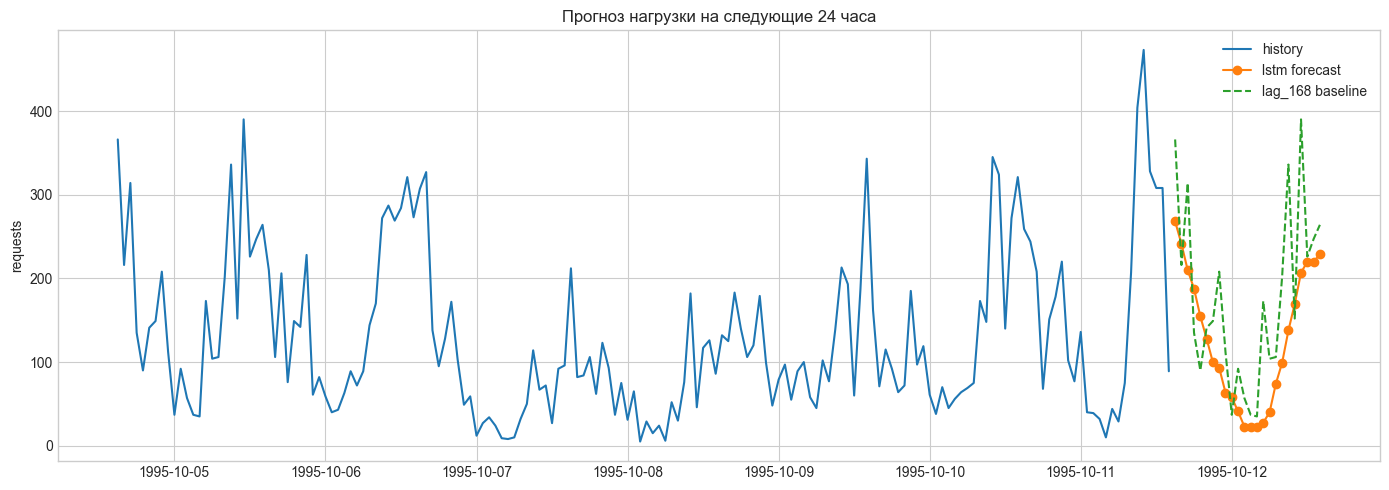

In [17]:
def forecast_next_24_hours(model: nn.Module, data: pd.DataFrame, mean: float, std: float) -> pd.DataFrame:
    history = data["requests"].to_numpy(dtype=np.float32)[-HISTORY_SIZE:]
    if len(history) < HISTORY_SIZE:
        raise ValueError(f"Need at least {HISTORY_SIZE} historical points")

    model.eval()
    X_last = torch.tensor(((history.reshape(1, HISTORY_SIZE, 1) - mean) / std), dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        lstm_forecast = model(X_last).cpu().numpy()[0] * std + mean

    last_timestamp = data["timestamp"].iloc[-1]
    future_index = pd.date_range(last_timestamp + pd.Timedelta(hours=1), periods=HORIZON, freq="h")

    return pd.DataFrame(
        {
            "timestamp": future_index,
            "seasonal_naive_lag_24": history[-HORIZON:],
            "seasonal_naive_lag_168": history[-HISTORY_SIZE : -HISTORY_SIZE + HORIZON],
            "lstm_forecast": np.clip(lstm_forecast, 0, None),
        }
    )


future_forecast = forecast_next_24_hours(lstm_model, df, request_mean, request_std)
display(future_forecast.head())

plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"].tail(7 * 24), df["requests"].tail(7 * 24), label="history", linewidth=1.5)
plt.plot(future_forecast["timestamp"], future_forecast["lstm_forecast"], label="lstm forecast", marker="o")
plt.plot(future_forecast["timestamp"], future_forecast["seasonal_naive_lag_168"], label="lag_168 baseline", linestyle="--")
plt.title("Прогноз нагрузки на следующие 24 часа")
plt.xlabel("")
plt.ylabel("requests")
plt.legend()
plt.tight_layout()

## Что вынести в `src/` после ноутбука

Когда эксперименты будут понятны, код удобно разложить так:

- `src/data.py`: генерация или загрузка данных;
- `src/features.py`: календарные признаки, лаги и rolling-признаки;
- `src/model.py`: `LSTMLoadForecaster`;
- `src/train.py`: обучение, early stopping, сохранение `.pt`;
- `src/predict.py`: загрузка модели и прогноз следующих 24 часов;
- `app/main.py`: FastAPI endpoint для запроса прогноза.

Для защиты проекта важно показать не только LSTM, а весь инженерный цикл: данные → бейзлайны → выбранная модель → сохранение → API → воспроизводимый запуск.